# 07 — EDA Block 3: Domestic Abuse and Minor Safety

**PACE Phase**: Analyze
**Objective**: analyze domestic crimes in depth — volume, trend,
victim profile, and modus operandi patterns. Specific focus on the
safety of minors, distinguishing between children (0-12), adolescents (13-17)
and adults (18+).

**Input**: `data/processed/crimes_features.parquet`

**Questions we answer**:
- Q3.1 — Overview of domestic crimes: volume, yearly trend, distribution by area
- Q3.2 — Victim profile comparison: domestic vs non-domestic crimes
- Q3.3 — Distribution by age group among domestic crime victims
- Q3.4 — Patterns in Mocodes for domestic crimes (requires MO_CODES.txt)

**Note**: domestic crimes are identified through the `is_domestic` column
(True/False) created during feature engineering. Total: 225,938 records (7.3%
of the dataset).

In [1]:
import pandas as pd             # Import the Pandas framework for DataFrame manipulation
import seaborn as sns           # Import Seaborn for statistical visualizations
import matplotlib.pyplot as plt # Import Matplotlib for plotting

pd.set_option('display.max_rows', None)         # Pandas setting to show all rows with inspection commands
pd.set_option('display.max_columns', None)      # Pandas setting to show all columns with inspection commands
pd.set_option('display.max_info_columns', 200)  # Pandas setting to show info for 200 columns with the '.info()' command

df = pd.read_parquet('../../data/processed/crimes_features.parquet') # Create the variable 'df' containing the
                                                                      # enriched dataset produced by 04_feature_engineering.ipynb
df.head() # Display the first 5 rows to recall the DataFrame's columns

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q3.1 — Overview of domestic crimes

We analyze domestic crimes (`is_domestic == True`) along three dimensions:
overall volume over the 2010–2024 period, yearly trend, and distribution
by LAPD area.

### Q3.1 - Volume of domestic crimes

In [2]:
distribution_domestic_crime_df = (
    df
    .groupby('is_domestic', as_index = False)
    .agg(count = ('is_domestic', 'count')) # Count records per True/False value of 'is_domestic'
).copy()

print(distribution_domestic_crime_df.head())

   is_domestic    count
0        False  2853486
1         True   225938


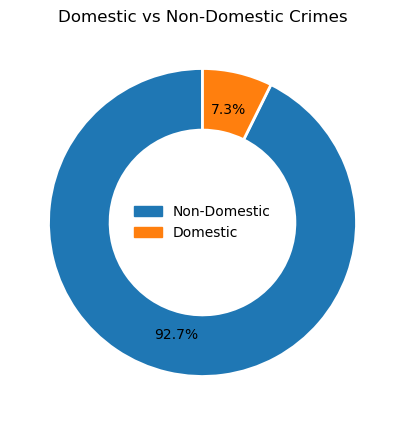

In [3]:
label_map = {True: 'Domestic', False: 'Non-Domestic'}
distribution_domestic_crime_df['label'] = distribution_domestic_crime_df['is_domestic'].map(label_map) # Map booleans to readable labels

fig, ax = plt.subplots(figsize=(5, 5)) # Create the figure

wedges, texts, autotexts = ax.pie(
    distribution_domestic_crime_df['count'],
    wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'}, # 'width' < 1 turns the pie into a donut
    autopct='%1.1f%%', # Show the percentage on each wedge
    startangle=90,
    pctdistance=0.75
)

labels = distribution_domestic_crime_df['label'].tolist()
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=wedges[i].get_facecolor(), label=labels[i]) # One legend swatch per wedge
    for i in range(len(wedges))
]

ax.legend(
    handles=legend_elements,
    loc='center', # Legend placed in the donut's hollow center
    frameon=False,
    fontsize=10
)

ax.set_title('Domestic vs Non-Domestic Crimes')

plt.savefig('../../outputs/07_eda_block3/15_donut_domestic_vs_nondomestic.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q3.1 — Volume of domestic crimes

Domestic crimes account for **7.3%** of the total crimes recorded by the LAPD over the 2010–2024 period (225,938 out of 3,079,424 records).

**Methodological note**: the `is_domestic` flag is based on keywords in the LAPD codes (`INTIMATE PARTNER`, `CHILD ABUSE`, etc.). Crimes with domestic dynamics but classified under generic codes (e.g. `BATTERY - SIMPLE ASSAULT` without context specification) are not captured by this flag. This percentage should therefore be interpreted as a **lower bound** rather than an accurate estimate of the real phenomenon.

### Creating a DataFrame dedicated to domestic crimes

In [4]:
q3_df = df[df['is_domestic'] == True].copy() # Isolate domestic crimes into a dedicated DataFrame for Block 3
q3_df['is_domestic'].value_counts() # Display the count, as a sanity check that only True rows remain

is_domestic
True    225938
Name: count, dtype: int64

### Q3.1 - Time trend of domestic crimes

In [5]:
q31_df_trend = (
    q3_df
    .groupby('year', as_index = False)
    .agg(count = ('year', 'count')) # Count domestic crimes per year
)
print(q31_df_trend.head())

   year  count
0  2010  15037
1  2011  14223
2  2012  14489
3  2013  13540
4  2014  15771


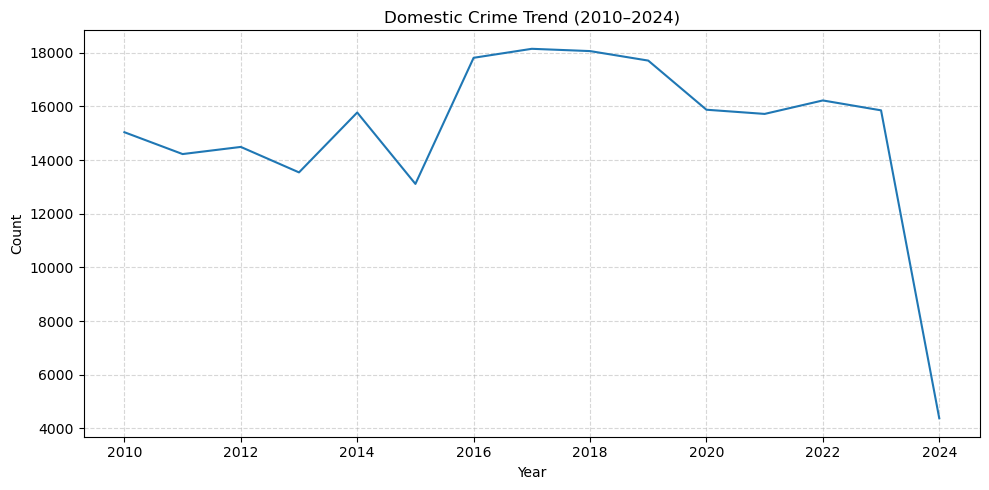

In [6]:
fig, ax = plt.subplots(figsize=(10, 5)) # Create the figure

sns.lineplot(
    data=q31_df_trend,
    x='year',
    y='count',
    ax=ax
)

ax.set_title('Domestic Crime Trend (2010–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/16_lineplot_domestic_crime_trend.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q3.1 — Yearly trend of domestic crimes

The chart shows that domestic crime follows a **declining trend from 2010 to 2013**, followed by an initial spike in **2014** (~ 15,700).

The **anomalous behavior of 2015–2016** is visible here as well, consistent with the pattern observed across all charts. The rebound in 2016 leads to a sharp rise, with the series reaching its **peak in 2017–2018** (~ 18,000 occurrences).

From 2018 onwards, the trend shows a **gradual decline through 2020** (~ 16,000), followed by a period of **relative stability from 2020 to 2023** (~ 15,700–16,200).

The **sharp drop in 2024** reflects the anomalous behavior documented in the introductory methodological note.

### Q3.1 - Distribution by LAPD area

In [7]:
q31_df_areaDist = (
    q3_df
    .groupby('AREA NAME', as_index=False)
    .agg(count = ('AREA NAME', 'count')) # Count domestic crimes per LAPD area
).sort_values('count', ascending = False)

print(q31_df_areaDist.head())

      AREA NAME  count
0   77th Street  21073
14    Southeast  17418
15    Southwest  15459
7       Mission  13022
9        Newton  12984


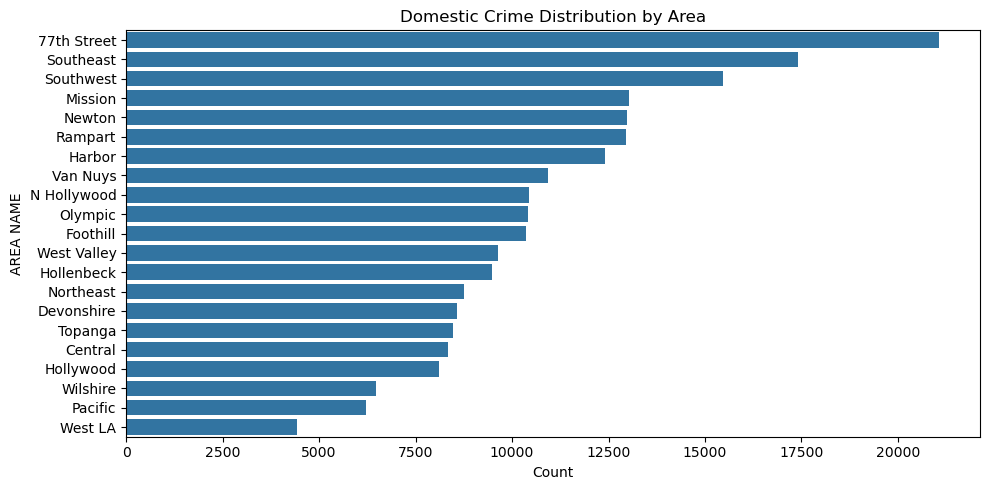

In [8]:
fig, ax = plt.subplots(figsize=(10, 5)) # Create the figure

sns.barplot(
    data=q31_df_areaDist,
    x='count',
    y='AREA NAME',
    ax=ax
)

ax.set_title('Domestic Crime Distribution by Area')
ax.set_xlabel('Count')
ax.set_ylabel('AREA NAME')

plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/17_barh_domestic_crime_by_area.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q3.1 — Distribution by LAPD area

The chart shows an uneven distribution of domestic crimes across the
21 LAPD areas, with three distinct groups:

- **High group** — 77th Street (21,073), Southeast (17,431), Southwest
  (15,726): the three areas with the highest volume of domestic crimes, with
  a significant gap over the rest.

- **Mid group** — Mission, Newton, Rampart, Harbor (~12,000–13,000):
  a group of areas with similar values to each other.

- **Low group** — West LA (4,447), Pacific (6,306), Wilshire (6,990):
  the three areas with the lowest volume of recorded domestic crimes.

**Methodological note**: the values are absolute counts. Without
per-district population data it isn't possible to compute a rate per 1,000
residents, which could change the ranking.

## 3. Q3.2 — Victim profile comparison: domestic vs non-domestic crimes

We compare the demographic profile of victims (sex, age, descent)
between domestic and non-domestic crimes. Goal: identify whether
significant differences exist in the victim profile depending on the
context of the offense.

In [9]:
q32_df = df[['age_group', 'Vict Sex', 'Vict Descent', 'is_domestic']].copy() # Keep only the columns needed for Q3.2

print(q32_df.head())

  age_group Vict Sex Vict Descent  is_domestic
0     Adult        M            H        False
1       NaN        M            W        False
2       NaN        M            H        False
3     Adult        F            W        False
4     Adult        F            H        False


In [10]:
q32_df_sex = (
    df
    .groupby(['Vict Sex', 'is_domestic'], as_index=False)
    .agg(count = ('Vict Sex', 'count')) # Count records per sex, split by domestic/non-domestic
).copy()

q32_df_age = (
    df
    .groupby(['age_group', 'is_domestic'], as_index=False, observed=True)
    .agg(count = ('Vict Age', 'count')) # Count records per age bracket, split by domestic/non-domestic
).copy()

q32_df_descent = (
    df
    .groupby(['Vict Descent', 'is_domestic'], as_index=False)
    .agg(count = ('Vict Descent', 'count')) # Count records per descent code, split by domestic/non-domestic
).copy()

print("Sex df")
print(q32_df_sex.head())
print('===========')
print("Age df")
print(q32_df_age.head())
print('===========')
print("Descent df")
print(q32_df_descent.head())

Sex df
  Vict Sex  is_domestic    count
0        F        False  1059290
1        F         True   171275
2        M        False  1305505
3        M         True    54336
4        X        False   488691
Age df
     age_group  is_domestic   count
0        Child        False   21141
1        Child         True   23147
2   Adolescent        False   69232
3   Adolescent         True   14924
4  Young Adult        False  881809
Descent df
  Vict Descent  is_domestic   count
0            -        False       5
1            A        False   68066
2            A         True    3222
3            B        False  407183
4            B         True   57537


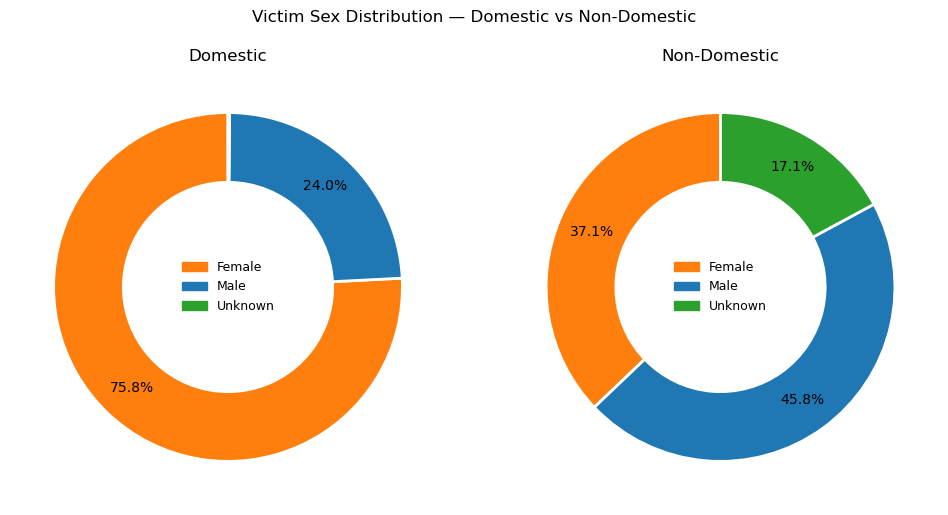

In [11]:
sex_isDomesticTrue_df = q32_df_sex[q32_df_sex['is_domestic'] == True].copy()   # Split off the domestic rows
sex_isDomesticFalse_df = q32_df_sex[q32_df_sex['is_domestic'] == False].copy() # Split off the non-domestic rows

sex_labels = {'F': 'Female', 'M': 'Male', 'X': 'Unknown'}
category_order = ['F', 'M', 'X'] # Fixed order so both pies use the same wedge order and colors
colors = ['#ff7f0e', '#1f77b4', '#2ca02c']  # blue, orange, green

sex_isDomesticTrue_df = sex_isDomesticTrue_df.set_index('Vict Sex').reindex(category_order).reset_index()   # Enforce the fixed order
sex_isDomesticFalse_df = sex_isDomesticFalse_df.set_index('Vict Sex').reindex(category_order).reset_index() # Enforce the fixed order

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) # Two side-by-side subplots, one per domestic/non-domestic

for ax, data, title in [
    (ax1, sex_isDomesticTrue_df, 'Domestic'),
    (ax2, sex_isDomesticFalse_df, 'Non-Domestic')
]:
    wedges, texts, autotexts = ax.pie(
        x=data['count'],
        startangle=90,
        colors=colors,
        wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'}, # 'width' < 1 turns the pie into a donut
        autopct=lambda p: f'{p:.1f}%' if p > 1 else '', # Hide the percentage label on slivers below 1%
        pctdistance=0.8
    )
    labels = [sex_labels[s] for s in category_order]
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, color=colors[i], label=labels[i]) # One legend swatch per category
        for i in range(len(category_order))
    ]
    ax.legend(handles=legend_elements, loc='center', frameon=False, fontsize=9)
    ax.set_title(title)

plt.suptitle('Victim Sex Distribution — Domestic vs Non-Domestic', y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/18_donut_victim_sex_domestic.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()


### Q3.2 — Victim profile comparison: Distribution by sex

The comparison between domestic and non-domestic crimes reveals a
clear difference in the gender distribution of victims.

**Domestic crimes**: Female 75.8%, Male 24.0%, Unknown <1%.
Women are the overwhelmingly dominant category in domestic crimes,
accounting for over three-quarters of victims.

**Non-domestic crimes**: Male 45.8%, Female 37.1%, Unknown 17.1%.
The distribution is much more balanced. The Unknown share (17.1%)
reflects crimes with no identifiable direct victim (vehicle
theft, vandalism, etc.) where sex isn't recorded —
a category that is almost absent in domestic crimes, where the victim is always
an identified person.

**Key finding**: in domestic crimes the female share rises from 37.1%
to 75.8% — more than doubling compared to non-domestic crimes. This is the
sharpest difference observed so far in the entire project and
confirms the expected pattern regarding gender violence in a
domestic context.

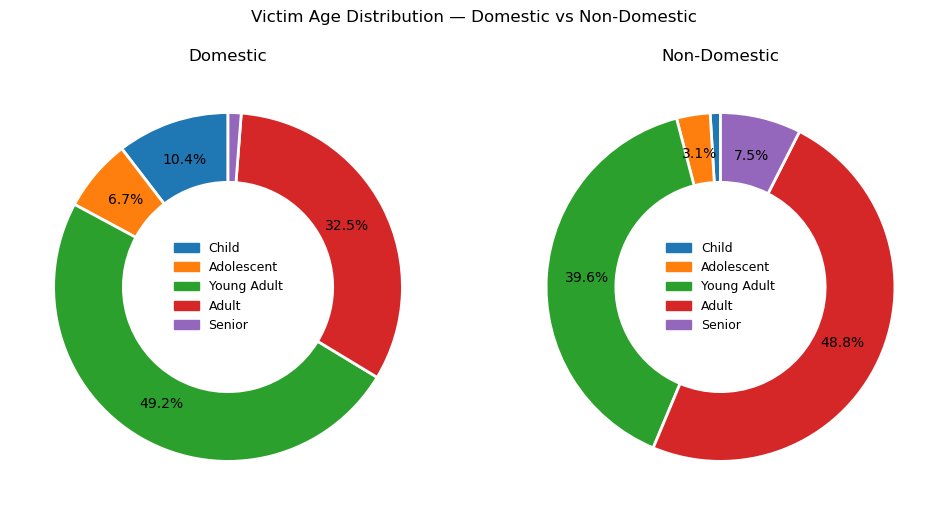

In [12]:
age_isDomesticTrue_df = q32_df_age[q32_df_age['is_domestic'] == True].copy()   # Split off the domestic rows
age_isDomesticFalse_df = q32_df_age[q32_df_age['is_domestic'] == False].copy() # Split off the non-domestic rows

age_order = ['Child', 'Adolescent', 'Young Adult', 'Adult', 'Senior'] # Chronological order for both pies
colors_age = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

age_isDomesticTrue_df = age_isDomesticTrue_df.set_index('age_group').reindex(age_order).reset_index()   # Enforce the fixed order
age_isDomesticFalse_df = age_isDomesticFalse_df.set_index('age_group').reindex(age_order).reset_index() # Enforce the fixed order

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) # Two side-by-side subplots, one per domestic/non-domestic

for ax, data, title in [
    (ax1, age_isDomesticTrue_df, 'Domestic'),
    (ax2, age_isDomesticFalse_df, 'Non-Domestic')
]:
    wedges, texts, autotexts = ax.pie(
        x=data['count'],
        startangle=90,
        colors=colors_age,
        wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'}, # 'width' < 1 turns the pie into a donut
        autopct=lambda p: f'{p:.1f}%' if p > 3 else '', # Hide the percentage label on slivers below 3%
        pctdistance=0.77
    )
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, color=colors_age[i], label=age_order[i]) # One legend swatch per age bracket
        for i in range(len(age_order))
    ]
    ax.legend(handles=legend_elements, loc='center', frameon=False, fontsize=9)
    ax.set_title(title)

plt.suptitle('Victim Age Distribution — Domestic vs Non-Domestic', y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/19_donut_victim_age_domestic.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Q3.2 — Victim profile comparison: Distribution by age group

**Young Adult / Adult reversal**: in domestic crimes, Young Adults
(18-34) are the dominant category with 49.2%, while in non-domestic crimes
Adults (35-64) lead with 48.8%. The two groups swap
positions between the two contexts.

**Child / Senior reversal**: in domestic crimes, children (0-12)
account for 10.4% of victims, while Seniors are almost absent
(<1%). In non-domestic crimes it's the opposite: Senior 7.5%, Child almost
absent. The domestic context is specifically dangerous for minors,
the non-domestic context for the elderly.

**Key finding — overrepresentation of minors in domestic crimes**:
in the overall dataset, children accounted for 1.8% of total
victims. In domestic crimes this share rises to 10.4% — an
overrepresentation of nearly 6 times. Q3.3 will dig deeper into this
topic with the detailed distribution by age group in domestic
crimes.

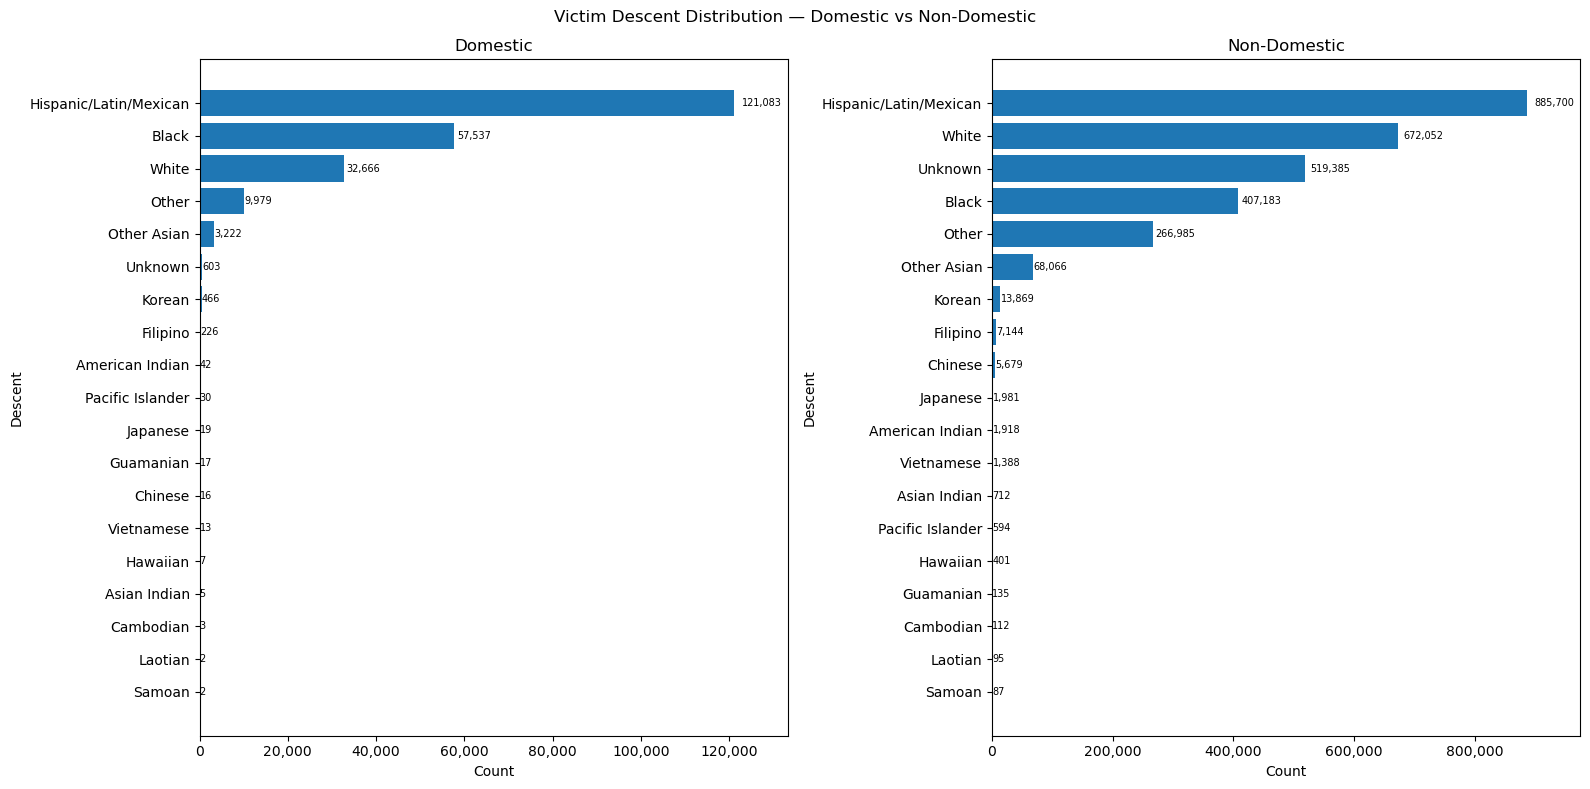

In [13]:
descent_isDomesticTrue_df = q32_df_descent[q32_df_descent['is_domestic'] == True]   # Split off the domestic rows
descent_isDomesticFalse_df = q32_df_descent[q32_df_descent['is_domestic'] == False] # Split off the non-domestic rows

descent_labels = {
    'A': 'Other Asian',
    'B': 'Black',
    'C': 'Chinese',
    'D': 'Cambodian',
    'F': 'Filipino',
    'G': 'Guamanian',
    'H': 'Hispanic/Latin/Mexican',
    'I': 'American Indian',
    'J': 'Japanese',
    'K': 'Korean',
    'L': 'Laotian',
    'O': 'Other',
    'P': 'Pacific Islander',
    'S': 'Samoan',
    'U': 'Hawaiian',
    'V': 'Vietnamese',
    'W': 'White',
    'X': 'Unknown',
    'Z': 'Asian Indian',
    '-': 'Unknown'
} # Descent code labels, from the LAPD Crime Data Dictionary (data.lacity.org)

# Map codes to labels, aggregate counts by label, and sort ascending — shared by both the domestic and non-domestic frames
def prepare_descent_df(df):
    df = df.copy()
    df['label'] = df['Vict Descent'].map(descent_labels)
    df = df.groupby('label', as_index=False)['count'].sum() # Sum counts of codes sharing the same label (e.g. '-' and 'X' both map to 'Unknown')
    df = df.sort_values('count', ascending=True)
    return df

domestic_plot_df = prepare_descent_df(descent_isDomesticTrue_df)
non_domestic_plot_df = prepare_descent_df(descent_isDomesticFalse_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8)) # Two side-by-side subplots, one per domestic/non-domestic

for ax, data, title in [
    (ax1, domestic_plot_df, 'Domestic'),
    (ax2, non_domestic_plot_df, 'Non-Domestic')
]:
    bars = ax.barh(y=data['label'], width=data['count'])
    for bar, value in zip(bars, data['count']): # Add a value label at the end of each bar
        ax.text(
            bar.get_width() + bar.get_width() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{int(value):,}',
            va='center', ha='left',
            fontsize=7
        )
    ax.margins(x=0.10)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format x-axis ticks with thousands separators
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('Descent')

plt.suptitle('Victim Descent Distribution — Domestic vs Non-Domestic')
plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/20_barh_victim_descent_domestic.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Q3.2 — Victim profile comparison: Distribution by descent

**Domestic crimes (top 3)**: Hispanic/Latin/Mexican (121,083), Black (57,537), White (32,666).

**Non-domestic crimes (top 3)**: Hispanic/Latin/Mexican (885,700), White (672,052), Unknown (519,385).

**Hispanic/Latin/Mexican** is the top category in both contexts, with a significantly higher share in domestic crimes relative to their position in non-domestic crimes.

**Black/White reversal**: in domestic crimes, Black victims rank second while White victims rank third. In non-domestic crimes the situation reverses: White in second place, Black in fourth. The relative shift between the two contexts is directly observable from the data.

**Unknown almost absent in domestic crimes**: in non-domestic crimes Unknown ranks third (519,385); in domestic crimes it drops to 603 occurrences. In domestic crimes the victim is always an identified person, unlike non-domestic crimes where the victim is often unidentified.

**Methodological note**: the values are absolute counts. Without population data by ethnic group it is not possible to assess over/underrepresentation. The comparison between the two contexts (domestic vs non-domestic) remains methodologically valid because both refer to the same base dataset.

## 4. Q3.3 — Distribution by age group among domestic crime victims

We analyze the distribution of domestic crime victims by age
group, with a specific focus on minors. The groups are:
- **Child** (0-12): children
- **Adolescent** (13-17): adolescents
- **Young Adult** (18-34), **Adult** (35-64), **Senior** (65+): adults

Goal: quantify minors' exposure to domestic crimes and
identify differences by crime type and by LAPD area.

In [14]:
q33_df = df.loc[
    (df['is_domestic'] == True) &
    (df['age_group'].isin(['Child', 'Adolescent'])), # Keep only domestic crimes with a minor victim
    ['Crm Cd Desc', 'age_group']
].copy()
print(q33_df.head())
print("=======")
print(q33_df.shape)
print("=======")
print(q33_df['age_group'].unique())
print("=======")
print(q33_df['Crm Cd Desc'].unique())

                                           Crm Cd Desc age_group
16                      CHILD NEGLECT (SEE 300 W.I.C.)     Child
84             CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT     Child
219                     CHILD NEGLECT (SEE 300 W.I.C.)     Child
298  CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...     Child
357            CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT     Child
(38071, 2)
['Child', 'Adolescent']
Categories (5, object): ['Child' < 'Adolescent' < 'Young Adult' < 'Adult' < 'Senior']
['CHILD NEGLECT (SEE 300 W.I.C.)'
 'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT'
 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)'
 'CHILD ANNOYING (17YRS & UNDER)'
 'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT'
 'INTIMATE PARTNER - SIMPLE ASSAULT'
 'INTIMATE PARTNER - AGGRAVATED ASSAULT' 'CHILD STEALING'
 'CHILD ABANDONMENT' 'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)']


In [15]:
q33_df_grouped = (
    q33_df
    .groupby(['Crm Cd Desc', 'age_group'], as_index = False, observed=True)
    .agg(count = ('Crm Cd Desc', 'count')) # Count records per crime type and minor age bracket
).copy()

print(q33_df_grouped)

                                          Crm Cd Desc   age_group  count
0                                   CHILD ABANDONMENT       Child     63
1                                   CHILD ABANDONMENT  Adolescent     25
2         CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT       Child   1066
3         CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT  Adolescent    769
4             CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT       Child   7403
5             CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT  Adolescent   4668
6                      CHILD ANNOYING (17YRS & UNDER)       Child   2414
7                      CHILD ANNOYING (17YRS & UNDER)  Adolescent   3535
8                      CHILD NEGLECT (SEE 300 W.I.C.)       Child   4082
9                      CHILD NEGLECT (SEE 300 W.I.C.)  Adolescent    907
10                                     CHILD STEALING       Child    120
11                                     CHILD STEALING  Adolescent     28
12  CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 .

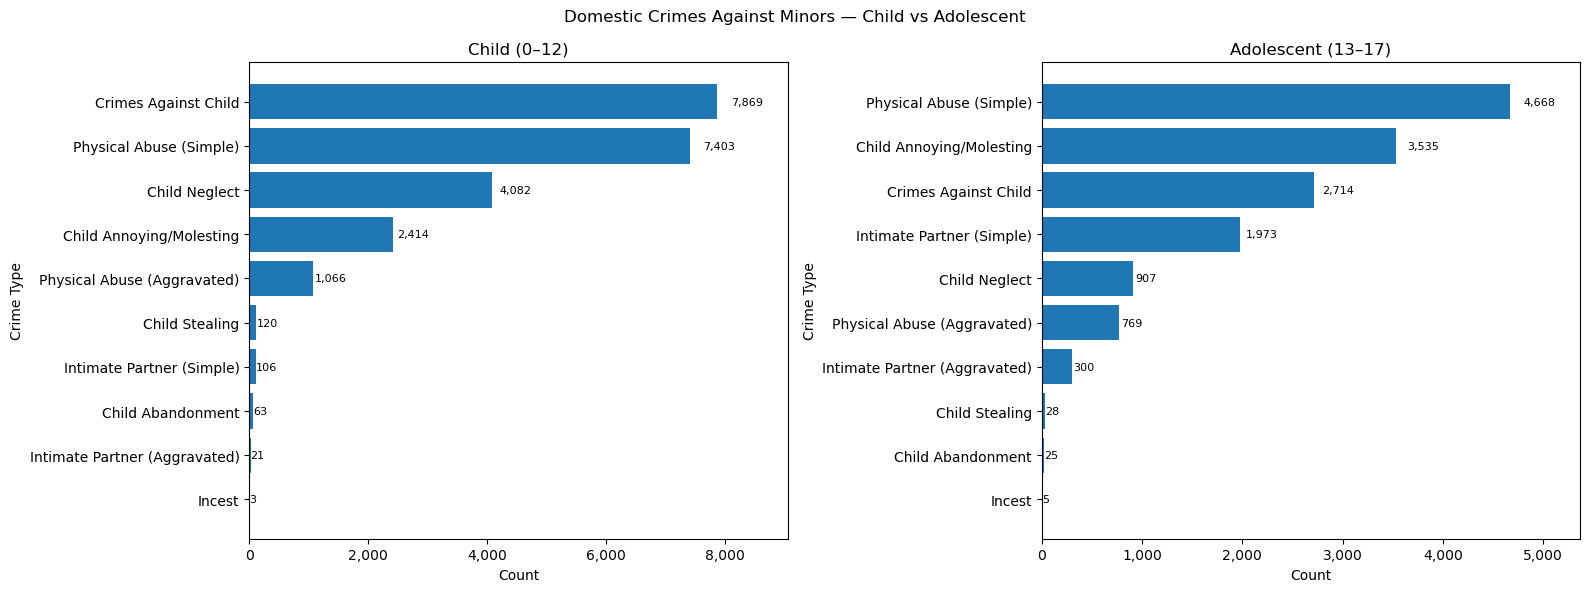

In [16]:
q33_child_df = q33_df_grouped[q33_df_grouped['age_group'] == "Child"].copy()      # Split off Child rows
q33_adolescent_df = q33_df_grouped[q33_df_grouped['age_group'] == 'Adolescent'].copy() # Split off Adolescent rows

crime_labels_minors = {
    'CHILD ABANDONMENT': 'Child Abandonment',
    'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT': 'Physical Abuse (Aggravated)',
    'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT': 'Physical Abuse (Simple)',
    'CHILD ANNOYING (17YRS & UNDER)': 'Child Annoying/Molesting',
    'CHILD NEGLECT (SEE 300 W.I.C.)': 'Child Neglect',
    'CHILD STEALING': 'Child Stealing',
    'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)': 'Crimes Against Child',
    'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)': 'Incest',
    'INTIMATE PARTNER - AGGRAVATED ASSAULT': 'Intimate Partner (Aggravated)',
    'INTIMATE PARTNER - SIMPLE ASSAULT': 'Intimate Partner (Simple)'
} # Abbreviated names for readability in the chart

q33_child_df['label'] = q33_child_df['Crm Cd Desc'].map(crime_labels_minors)
q33_adolescent_df['label'] = q33_adolescent_df['Crm Cd Desc'].map(crime_labels_minors)

q33_child_df = q33_child_df.sort_values('count', ascending=True)
q33_adolescent_df = q33_adolescent_df.sort_values('count', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) # Two side-by-side subplots, one per age bracket

for ax, data, title in [
    (ax1, q33_child_df, 'Child (0–12)'),
    (ax2, q33_adolescent_df, 'Adolescent (13–17)')
]:
    bars = ax.barh(y=data['label'], width=data['count'])
    for bar, value in zip(bars, data['count']): # Add a value label at the end of each bar
        ax.text(
            bar.get_width() + bar.get_width() * 0.03,
            bar.get_y() + bar.get_height() / 2,
            f'{int(value):,}',
            va='center', ha='left',
            fontsize=8
        )
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format x-axis ticks with thousands separators
    ax.margins(x=0.15)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('Crime Type')

plt.suptitle('Domestic Crimes Against Minors — Child vs Adolescent')
plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/21_barh_domestic_crimes_minors.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Q3.3 — Distribution by age group: domestic crimes against minors

**Methodological note**: the crime category "Crimes Against Child" has been classified as sexual abuse based on the prevalence of 05xx MO codes (sex-related acts) in the associated records.

**Child group (0–12)**

The two dominant crimes are nearly equal in volume:
- **Crimes Against Child**: 7,869
- **Physical Abuse (Simple)**: 7,403

The third most frequent crime is **Child Neglect** (4,082). 

The remaining crimes — Child Stealing, Intimate Partner, Child Abandonment, Incest — show negligible values compared to the top three.

**Adolescent group (13–17)**

The distribution is more balanced than in the Child group:
- **Physical Abuse (Simple)**: 4,668
- **Child Annoying/Molesting**: 3,535
- **Crimes Against Child**: 2,714
- **Intimate Partner (Simple)**: 1,973

Three key differences from the Child group:
1. **Child Neglect drops sharply**: from 4,082 to 907.
2. **Child Annoying/Molesting rises**: from 2,414 to 3,535.
3. **Intimate Partner emerges**: nearly absent in the Child group (106 and 21), it becomes significant among adolescents (1,973 and 300).

## 5. Q3.4 — Patterns in Mocodes for domestic crimes

Mocodes (modus operandi codes) describe the way in which
the crime was committed. Each record can have multiple codes separated
by a space (e.g. "0913 1814 2000").

We analyze which Mocodes recur most frequently in domestic crimes
to identify modus operandi patterns. Focus on:
- Codes related to physical violence (0400 series)
- Codes related to sexual acts (0500 series)
- Codes related to the suspect-victim relationship (1800 series)
- Code 2000 (Domestic Violence) — explicit LAPD flag

**Source**: LAPD MO Codes Numerical List, rev. 05/18

In [17]:
q34_df = q3_df[q3_df['Mocodes'].notna()] # Keep only domestic crimes with at least one recorded Mocode

codes = q34_df['Mocodes'].str.split().explode() # Split the space-separated codes and turn each into its own row
print(codes.head(10))
print('======')
print(len(codes)) # Total number of individual codes across all domestic crimes

16    1251
18    2000
20    0416
20    2000
25    0416
42    0400
42    2000
47    2000
48    0400
48    0408
Name: Mocodes, dtype: object
1004602


In [18]:
print(codes.value_counts().head(30)) # Display the 30 most frequent individual Mocodes

Mocodes
2000    178361
0416    115673
1814     70790
0913     69305
0400     54321
1813     54293
0444     39983
0448     28115
1243     25413
0408     22738
0429     19502
0446     16707
1258     14779
0419     13151
1251     11467
0417     11000
2002     10991
1309     10916
1402     10144
0432      9710
1259      8736
1241      8546
1257      7030
1414      7009
2004      6975
0522      6957
0401      6710
1821      6649
0447      6244
0552      5938
Name: count, dtype: int64


In [19]:
mo_codes_dic = {
   '2000': 'Domestic Violence',
   '0416': 'Hit with weapon',
   '1814': 'Boyfriend/Girlfriend',
   '0913': 'Victim knew Suspect',
   '0400': 'Force used',
   '1813': 'Spouse/Cohabitant',
   '0444': 'Pushed',
   '0448': 'Grabbed',
   '1243': 'Co-habitants',
   '0408': 'Choked/Strangled',
   '0429': 'Knocked to ground',
   '0446': 'Swung fist',
   '1258': 'Victim is 6-13 years old',
   '0419': 'Pulled hair',
   '1251': 'Victim was a student',
   '0417': 'Kicked',
   '2002': 'Suspect intoxicated/drunk',
   '1309': 'Suspect uses vehicle',
   '1402': 'Evidence booked',
   '0432': 'Intimidation',
   '1259': 'Victim is 14-17 years old',
   '1241': 'Spouse',
   '1257': 'Victim is newborn-5 years old',
   '1414': 'Photographs',
   '2004': 'Suspect is homeless/transient',
   '0522': 'Touched',
   '0401': 'Bit',
   '1821': 'Spouse',
   '0447': 'Suspect swung weapon',
   '0552': 'Suspect is Father'
} # Descriptions for the 30 most frequent codes, from the LAPD MO Codes Numerical List (rev. 05/18)

codes_df = codes.reset_index(drop=True).to_frame(name='code') # Turn the exploded codes Series into a DataFrame

codes_df['description'] = codes_df['code'].map(mo_codes_dic) # Map each code to its description; codes outside
                                                              # the top 30 dictionary become NaN

codes_filtered = codes_df[codes_df['description'].notna()] # Keep only codes with a known description

mo_freq_df = (
    codes_filtered
    .groupby('description', as_index=False)
    .agg(count=('description', 'count')) # Count occurrences of each described code
    .sort_values('count', ascending=False)
)

print(mo_freq_df)

                      description   count
4               Domestic Violence  178361
8                 Hit with weapon  115673
1            Boyfriend/Girlfriend   70790
27            Victim knew Suspect   69305
6                      Force used   54321
16              Spouse/Cohabitant   54293
14                         Pushed   39983
7                         Grabbed   28115
3                    Co-habitants   25413
2                Choked/Strangled   22738
11              Knocked to ground   19502
22                     Swung fist   16707
15                         Spouse   15195
25       Victim is 6-13 years old   14779
13                    Pulled hair   13151
28           Victim was a student   11467
10                         Kicked   11000
17      Suspect intoxicated/drunk   10991
21           Suspect uses vehicle   10916
5                 Evidence booked   10144
9                    Intimidation    9710
24      Victim is 14-17 years old    8736
26  Victim is newborn-5 years old 

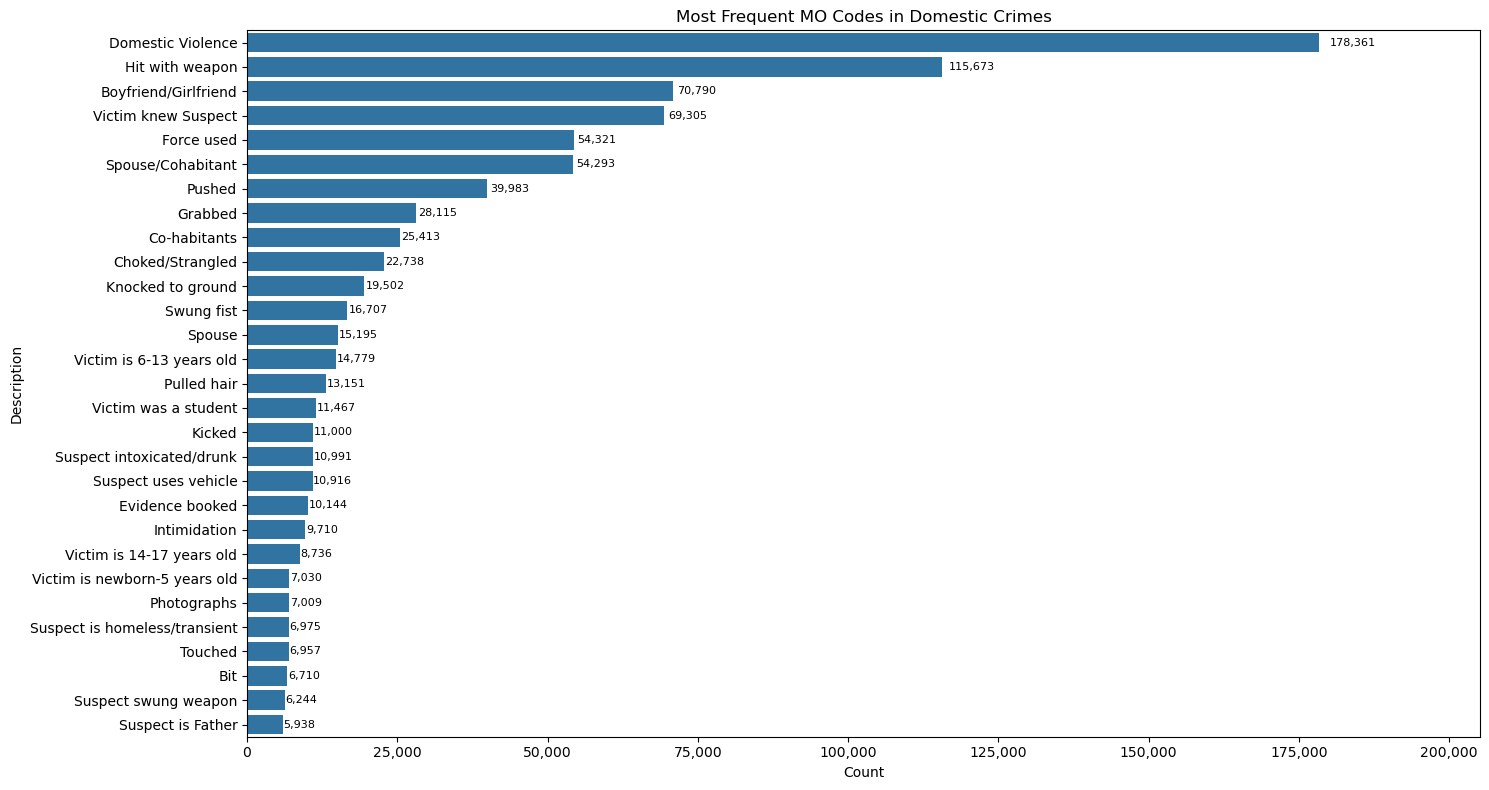

In [20]:
fig, ax = plt.subplots(figsize=(15, 8)) # Create the figure

bars = sns.barplot(
    data=mo_freq_df,
    x='count',
    y='description',
    ax=ax
)

for bar, value in zip(ax.patches, mo_freq_df['count']): # Add a value label at the end of each bar
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(value):,}',
        va='center', ha='left',
        fontsize=8
    )

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format x-axis ticks with thousands separators
ax.margins(x=0.15)
ax.set_title('Most Frequent MO Codes in Domestic Crimes')
ax.set_xlabel('Count')
ax.set_ylabel('Description')

plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/22_barh_mo_codes_domestic.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Q3.4 — Patterns in Mocodes for domestic crimes

**Methodological note**: MO codes (Modus Operandi) describe the details of the crime. Each record can have multiple codes. The analysis is based on the 30 most frequent codes among the 224,201 domestic crimes with recorded MO codes.

---

**Domestic Violence (2000) — 178,361**: this is the generic LAPD flag applied to all crimes with a domestic dynamic. Its dominant presence confirms that the MO codes field is systematically filled in for domestic crimes.

**Hit with weapon (0416) — 115,673**: second most frequent code, indicating that the victim was struck with an object used as a weapon.

**Suspect-victim familiarity pattern**: four codes confirm that in the vast majority of cases the suspect is someone the victim knows intimately:
- Boyfriend/Girlfriend (1814): 70,790
- Victim knew Suspect (0913): 69,305
- Spouse/Cohabitant (1813): 54,293
- Co-habitants (1243): 25,413

**Modes of physical violence**: the codes in the 0400 series show the variety of physical methods used. Worth noting in particular is **Choked/Strangled (0408) — 22,738**. Note: strangulation is documented as a high-risk escalation indicator in intimate partner violence (Glass et al., 2008, Journal of Emergency Medicine).

**Minor victims**: the presence of three age-specific codes confirms the findings from Q3.3:
- Victim is 6–13 years old (1258): 14,779
- Victim is 14–17 years old (1259): 8,736
- Victim is newborn–5 years old (1257): 7,030

**Suspect intoxicated/drunk (2002) — 10,991**: the suspect's intoxication is recorded in approximately 5% of cases.

**Suspect is Father (0552) — 5,938**: the father's presence as suspect in cases involving minors is consistent with the patterns identified in Q3.3.